# Task 2.6 — SFT Multi-Agent Signal Consolidation

Same 4-agent pipeline as Task 2.4, but using SFT-rescored factors.

## Architecture

```
┌──────────────────┐     ┌───────────────────┐     ┌──────────────────────┐     ┌────────────────────┐
│  Agent 1          │     │  Agent 2           │     │  Agent 3              │     │  Agent 4            │
│  Factor Sentiment │────▶│  Category          │────▶│  Sub-Sector Context   │────▶│  Signal             │
│  (load SFT-scored)│     │  Aggregator        │     │  (key drivers/risks)  │     │  Consolidator       │
└──────────────────┘     └───────────────────┘     └──────────────────────┘     └────────────────────┘
```

| Input | Source |
|-------|--------|
| SFT-scored factors | `output/factors_scored_sft/{TICKER}/*.json` |
| Filing returns | `../task_1/output/filing_returns.csv` |
| Reasoning ICs | `../task_1/output/reasoning_output.json` |
| Ticker mapping | `../task_1/ticker_mapping.json` |

| Output | Destination |
|--------|-------------|
| Filing signals (SFT) | `output/filing_signals_sft.jsonl` |
| Comparison charts | Inline |

In [1]:
import json
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

# ── Paths ────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
TASK1_DIR = (_cwd.parent / "task_1").resolve() if (_cwd.parent / "task_1").exists() else (_cwd / ".." / "task_1").resolve()

# SFT-rescored factors live under task_2/output/
FACTORS_SCORED_DIR = _cwd / "output" / "factors_scored_sft"
RETURNS_PATH       = TASK1_DIR / "output" / "filing_returns.csv"
REASONING_PATH     = TASK1_DIR / "output" / "reasoning_output.json"
TICKER_MAP_PATH    = TASK1_DIR / "ticker_mapping.json"
OUTPUT_DIR         = _cwd / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Base signals for comparison (produced by task_2_4)
BASE_SIGNALS_PATH = OUTPUT_DIR / "filing_signals.jsonl"

# ── Constants ────────────────────────────────────────────────────────────
LABEL_ORDER = ["very_negative", "negative", "neutral", "positive", "very_positive"]
LABEL_TO_SCORE = {
    "very_negative": -2,
    "negative": -1,
    "neutral": 0,
    "positive": 1,
    "very_positive": 2,
}
COHORT_THRESHOLDS = [
    ("very_negative", -np.inf, -0.6),
    ("negative",      -0.6,   -0.2),
    ("neutral",       -0.2,    0.2),
    ("positive",       0.2,    0.6),
    ("very_positive",  0.6,    np.inf),
]

# ── Load ticker mapping ─────────────────────────────────────────────────
with open(TICKER_MAP_PATH) as f:
    _ticker_map = json.load(f)

TICKER_SUBSECTOR: dict[str, str] = {}
for subsector, tickers in _ticker_map.items():
    for t in tickers:
        TICKER_SUBSECTOR[t] = subsector

# ── Load filing returns ──────────────────────────────────────────────────
returns_df = pd.read_csv(RETURNS_PATH)
returns_df["filing_date"] = pd.to_datetime(returns_df["filing_date"])
returns_df = returns_df[returns_df["status"] == "ok"].copy()
returns_df = returns_df.dropna(subset=["ret_21d_excess"])

# ── Load reasoning ICs ───────────────────────────────────────────────────
with open(REASONING_PATH) as f:
    reasoning_data = json.load(f)

ic_rows = []
for sector in reasoning_data["sectors"]:
    for item in reasoning_data["sector_reasoning"][sector].get("sentiment_return_link", []):
        ic_rows.append({
            "sector": sector,
            "factor_key": item["factor"],
            "IC": item["IC"],
            "hit_rate": item["hit_rate"],
        })
ic_df = pd.DataFrame(ic_rows)

# ── Logging ──────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)
log = logging.getLogger("task_2_6")

# ── Summary ──────────────────────────────────────────────────────────────
print(f"Task 1 dir:          {TASK1_DIR}")
print(f"Factors scored dir:  {FACTORS_SCORED_DIR} (exists={FACTORS_SCORED_DIR.exists()})")
print(f"Returns:             {len(returns_df)} filings (status=ok)")
print(f"Return stats:        mean={returns_df['ret_21d_excess'].mean():.4f}, "
      f"std={returns_df['ret_21d_excess'].std():.4f}")
print(f"IC data:             {len(ic_df)} factor-sector pairs across {ic_df['sector'].nunique()} sectors")
print(f"Tickers:             {len(TICKER_SUBSECTOR)} across {len(_ticker_map)} sub-sectors")
print(f"Base signals exist:  {BASE_SIGNALS_PATH.exists()}")
print(f"\nIC summary:")
print(ic_df.to_string(index=False))

Task 1 dir:          /panfs/accrepfs.vampire/home/sivakur/asset/fillings/roshan/Actual_code/task_1
Factors scored dir:  /panfs/accrepfs.vampire/home/sivakur/asset/fillings/roshan/Actual_code/task_2/output/factors_scored_sft (exists=True)
Returns:             2441 filings (status=ok)
Return stats:        mean=0.0047, std=0.0704
IC data:             16 factor-sector pairs across 4 sectors
Tickers:             86 across 4 sub-sectors
Base signals exist:  True

IC summary:
              sector           factor_key      IC  hit_rate
            airlines interest_rate_impact  0.0999      0.54
            airlines         new_products -0.0796      0.49
            airlines          fx_exposure -0.0520      0.46
            airlines         cost_actions  0.0380      0.54
             defense interest_rate_impact -0.0796      0.54
             defense         new_products -0.0566      0.49
             defense        capex_outlook -0.0488      0.51
             defense        trade_tariffs  0.0

## Agent 1 — Load SFT-Scored Factors

Load all factor JSONs from `output/factors_scored_sft/` into a flat DataFrame.
Each factor has a 5-class sentiment label assigned by the SFT-fine-tuned model (task 2.5).

In [2]:
rows = []
skipped = 0
files_loaded = 0

for ticker_dir in sorted(FACTORS_SCORED_DIR.iterdir()):
    if not ticker_dir.is_dir():
        continue
    ticker = ticker_dir.name
    subsector = TICKER_SUBSECTOR.get(ticker, "unknown")

    for fpath in sorted(ticker_dir.glob("*_factors.json")):
        with open(fpath) as f:
            data = json.load(f)

        files_loaded += 1
        form = data.get("form", "")
        filing_date = data.get("filing_date", "")

        for fac in data.get("factors", []):
            sentiment = fac.get("sentiment")
            if not isinstance(sentiment, dict) or not sentiment.get("label"):
                skipped += 1
                continue

            evidence_parts = []
            for ev in fac.get("evidence", []):
                text = ev.get("text", "").strip()
                if text:
                    evidence_parts.append(text)
            evidence_text = " | ".join(evidence_parts) if evidence_parts else ""

            rows.append({
                "ticker": ticker,
                "sub_sector": subsector,
                "form": form,
                "filing_date": filing_date,
                "key": fac.get("key", ""),
                "category": fac.get("category", ""),
                "summary": fac.get("summary", ""),
                "evidence_text": evidence_text,
                "label": sentiment["label"],
                "rationale": sentiment.get("rationale", ""),
                "confidence": sentiment.get("confidence", 0.0),
            })

factors_df = pd.DataFrame(rows)
factors_df["filing_date"] = pd.to_datetime(factors_df["filing_date"])
factors_df["score"] = factors_df["label"].map(LABEL_TO_SCORE)

# ── Drop hallucinated "unknown" category factors (1.5% of total) ────────
_before = len(factors_df)
factors_df = factors_df[factors_df["category"] != "unknown"].reset_index(drop=True)
print(f"Dropped unknown category: {_before - len(factors_df)} factors ({(_before - len(factors_df))/_before*100:.1f}%)")

print(f"Files loaded:         {files_loaded}")
print(f"Total factors:        {len(factors_df)}")
print(f"Skipped (no label):   {skipped}")
print(f"Unique tickers:       {factors_df['ticker'].nunique()}")
print(f"Unique filings:       {factors_df.groupby(['ticker', 'filing_date']).ngroups}")
print(f"Unique categories:    {factors_df['category'].nunique()}")
print(f"Unique factor keys:   {factors_df['key'].nunique()}")

print(f"\nLabel distribution:")
label_dist = factors_df["label"].value_counts().reindex(LABEL_ORDER)
for lbl, cnt in label_dist.items():
    print(f"  {lbl:16s}: {cnt:6d} ({cnt/len(factors_df):.1%})")

print(f"\nLabel x Sub-sector cross-tab:")
cross = pd.crosstab(factors_df["sub_sector"], factors_df["label"])
cross = cross.reindex(columns=LABEL_ORDER, fill_value=0)
print(cross.to_string())

Dropped unknown category: 986 factors (1.5%)
Files loaded:         2542
Total factors:        64304
Skipped (no label):   8894
Unique tickers:       83
Unique filings:       2539
Unique categories:    14
Unique factor keys:   60

Label distribution:
  very_negative   :   1995 (3.1%)
  negative        :  17393 (27.0%)
  neutral         :  15894 (24.7%)
  positive        :  25244 (39.3%)
  very_positive   :   3778 (5.9%)

Label x Sub-sector cross-tab:
label                 very_negative  negative  neutral  positive  very_positive
sub_sector                                                                     
airlines                        332      1674     1165      2167            422
defense                         397      2532     3320      4036            469
general                         602      6002     4870      7850           1177
industrial_equipment            664      7185     6539     11191           1710


## Agent 2 — Category Aggregator

For each filing, compute a **confidence-weighted average sentiment score** per category.
This reduces ~25 factors per filing into ~14 category-level scores.

In [3]:
def confidence_weighted_mean(group: pd.DataFrame) -> float:
    """Weighted average of score by confidence within a group."""
    w = group["confidence"].values
    s = group["score"].values
    total_w = w.sum()
    if total_w == 0:
        return s.mean()
    return (s * w).sum() / total_w


# Group by (ticker, filing_date, category) -> weighted avg score
cat_scores = (
    factors_df
    .groupby(["ticker", "filing_date", "category"])
    .apply(confidence_weighted_mean, include_groups=False)
    .rename("cat_score")
    .reset_index()
)

# Pivot: one row per (ticker, filing_date), one column per category
cat_pivot = cat_scores.pivot_table(
    index=["ticker", "filing_date"],
    columns="category",
    values="cat_score",
)
cat_pivot.columns.name = None

# Merge with returns
filing_df = cat_pivot.reset_index().merge(
    returns_df[["ticker", "filing_date", "form", "ret_21d_excess"]],
    on=["ticker", "filing_date"],
    how="inner",
)

# Add sub-sector
filing_df["sub_sector"] = filing_df["ticker"].map(TICKER_SUBSECTOR)

# Identify category columns
cat_cols = [c for c in cat_pivot.columns if c not in ("ticker", "filing_date")]

print(f"Filing DataFrame:     {filing_df.shape[0]} filings x {len(cat_cols)} categories")
print(f"Category columns:     {cat_cols}")
print(f"Matched with returns: {filing_df['ret_21d_excess'].notna().sum()}")
print(f"\nCategory coverage (fraction of filings with non-null score):")
coverage = filing_df[cat_cols].notna().mean().sort_values(ascending=False)
for cat, frac in coverage.items():
    print(f"  {cat:30s}: {frac:.1%}")

print(f"\nSample rows:")
filing_df[["ticker", "filing_date", "form", "sub_sector", "ret_21d_excess"] + cat_cols[:4]].head(5)

Filing DataFrame:     2438 filings x 14 categories
Category columns:     ['airlines_transport', 'capital_allocation', 'competitive_position', 'cost_margins', 'defense_government', 'demand_revenue', 'esg_sustainability', 'industrial_infrastructure', 'labor_workforce', 'macro_external', 'outlook_guidance', 'regulatory_legal', 'supply_chain_operations', 'technology_innovation']
Matched with returns: 2438

Category coverage (fraction of filings with non-null score):
  demand_revenue                : 96.9%
  cost_margins                  : 96.1%
  capital_allocation            : 89.5%
  outlook_guidance              : 88.8%
  macro_external                : 79.8%
  supply_chain_operations       : 63.7%
  regulatory_legal              : 60.3%
  competitive_position          : 48.8%
  labor_workforce               : 45.4%
  technology_innovation         : 39.0%
  industrial_infrastructure     : 24.0%
  defense_government            : 12.9%
  esg_sustainability            : 11.3%
  airlines_tr

,ticker,filing_date,form,sub_sector,ret_21d_excess,airlines_transport,capital_allocation,competitive_position,cost_margins
0,AAL,2015-02-25,10-K,airlines,0.056690,0.562500,1.494382,-0.027027,0.400000
1,AAL,2015-04-24,10-Q,airlines,-0.205430,-0.269841,0.557143,-0.238095,1.150943
2,AAL,2015-07-24,10-Q,airlines,0.040437,-1.028571,-0.265306,-1.000000,0.545455
3,AAL,2015-10-23,10-Q,airlines,-0.079311,0.209302,0.269841,-1.000000,1.098592
4,AAL,2016-02-24,10-K,airlines,-0.060704,-0.370370,0.479452,-0.531250,0.792049


## Agent 3 — Key Drivers & Risk Flags

For each filing, identify **key drivers** (top 3 positive categories) and **risk flags**
(top 3 negative categories). Flag sector-specific categories when they appear as
top drivers or risks.

In [4]:
SECTOR_SPECIFIC_CATS = {
    "airlines":              ["airlines_transport"],
    "defense":               ["defense_government"],
    "industrial_equipment":  ["industrial_infrastructure"],
    "general":               [],
}


def identify_drivers_and_risks(row: pd.Series) -> dict:
    """Rank categories by score; extract top-3 drivers and top-3 risks."""
    scores = {cat: row[cat] for cat in cat_cols if pd.notna(row[cat])}
    if not scores:
        return {"key_drivers": [], "risk_flags": [], "sector_context": ""}

    sorted_cats = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    # Key drivers: top-3 with positive score
    key_drivers = [cat for cat, sc in sorted_cats if sc > 0][:3]

    # Risk flags: bottom-3 with negative score
    risk_flags = [cat for cat, sc in sorted_cats[::-1] if sc < 0][:3]

    # Sector-specific context
    sub_sector = row.get("sub_sector", "")
    spec_cats = SECTOR_SPECIFIC_CATS.get(sub_sector, [])
    context_parts = []
    for sc in spec_cats:
        if sc in [d for d in key_drivers]:
            context_parts.append(f"{sc} is a key driver")
        elif sc in [r for r in risk_flags]:
            context_parts.append(f"{sc} is a risk flag")
    sector_context = "; ".join(context_parts) if context_parts else ""

    return {
        "key_drivers": key_drivers,
        "risk_flags": risk_flags,
        "sector_context": sector_context,
    }


agent3_results = filing_df.apply(identify_drivers_and_risks, axis=1, result_type="expand")
filing_df["key_drivers"] = agent3_results["key_drivers"]
filing_df["risk_flags"] = agent3_results["risk_flags"]
filing_df["sector_context"] = agent3_results["sector_context"]

# Stats
n_with_drivers = filing_df["key_drivers"].apply(len).gt(0).sum()
n_with_risks = filing_df["risk_flags"].apply(len).gt(0).sum()
n_with_context = filing_df["sector_context"].str.len().gt(0).sum()

print(f"Filings with key drivers:   {n_with_drivers} / {len(filing_df)}")
print(f"Filings with risk flags:    {n_with_risks} / {len(filing_df)}")
print(f"Filings with sector context:{n_with_context} / {len(filing_df)}")

# Most common drivers and risks
from collections import Counter
all_drivers = Counter(d for drivers in filing_df["key_drivers"] for d in drivers)
all_risks = Counter(r for risks in filing_df["risk_flags"] for r in risks)

print(f"\nTop-5 key drivers:")
for cat, cnt in all_drivers.most_common(5):
    print(f"  {cat:30s}: {cnt}")

print(f"\nTop-5 risk flags:")
for cat, cnt in all_risks.most_common(5):
    print(f"  {cat:30s}: {cnt}")

Filings with key drivers:   2307 / 2438
Filings with risk flags:    2014 / 2438
Filings with sector context:618 / 2438

Top-5 key drivers:
  capital_allocation            : 1455
  demand_revenue                : 1281
  cost_margins                  : 875
  technology_innovation         : 503
  competitive_position          : 456

Top-5 risk flags:
  macro_external                : 1201
  regulatory_legal              : 862
  cost_margins                  : 514
  outlook_guidance              : 478
  supply_chain_operations       : 460


## Agent 4 — IC-Weighted Signal

Compute the final filing-level signal as an **IC-weighted average** of category scores.
Weights = |IC| per factor (from `reasoning_output.json`), aggregated to category level
by averaging factor ICs within each category. Categories without IC data get equal weight.

In [5]:
# ── Build factor_key -> category mapping from actual factor data ───────────
key_to_cat = factors_df.groupby("key")["category"].first().to_dict()

# ── Build per-sector category-level IC weights ───────────────────────────
# Map factor-level ICs to categories, then average |IC| per category per sector
ic_df["category"] = ic_df["factor_key"].map(key_to_cat)
ic_df["abs_IC"] = ic_df["IC"].abs()

sector_cat_ic = (
    ic_df.dropna(subset=["category"])
    .groupby(["sector", "category"])["abs_IC"]
    .mean()
    .reset_index()
    .rename(columns={"abs_IC": "weight"})
)

print("IC-derived category weights per sector:")
for sector in sorted(sector_cat_ic["sector"].unique()):
    subset = sector_cat_ic[sector_cat_ic["sector"] == sector]
    print(f"\n  {sector}:")
    for _, r in subset.iterrows():
        print(f"    {r['category']:30s}: {r['weight']:.4f}")

# Default weight for categories without IC data
DEFAULT_WEIGHT = 1.0 / len(cat_cols)

# ── Compute IC-weighted signal per filing ─────────────────────────────────
def compute_signal(row: pd.Series) -> float:
    """IC-weighted sum of category scores, normalized to [-1, 1]."""
    sub_sector = row.get("sub_sector", "")
    # Get sector-specific weights
    sector_weights = sector_cat_ic[sector_cat_ic["sector"] == sub_sector]
    weight_map = dict(zip(sector_weights["category"], sector_weights["weight"]))

    weighted_sum = 0.0
    total_weight = 0.0

    for cat in cat_cols:
        val = row[cat]
        if pd.isna(val):
            continue
        w = weight_map.get(cat, DEFAULT_WEIGHT)
        weighted_sum += val * w
        total_weight += w

    if total_weight == 0:
        return 0.0
    return weighted_sum / total_weight


filing_df["signal"] = filing_df.apply(compute_signal, axis=1)

# Normalize to [-1, 1] via clipping at the score range extremes
# Max possible weighted avg is 2.0 (all very_positive), min is -2.0
filing_df["signal"] = filing_df["signal"].clip(-2, 2) / 2.0

# ── Assign cohort ────────────────────────────────────────────────────────
def assign_cohort(signal: float) -> str:
    for name, lo, hi in COHORT_THRESHOLDS:
        if lo <= signal < hi:
            return name
    return "very_positive"  # edge case: signal == 1.0


filing_df["cohort"] = filing_df["signal"].apply(assign_cohort)

# Enforce categorical ordering
filing_df["cohort"] = pd.Categorical(filing_df["cohort"], categories=LABEL_ORDER, ordered=True)

print(f"\nSignal statistics:")
print(f"  mean:   {filing_df['signal'].mean():.4f}")
print(f"  std:    {filing_df['signal'].std():.4f}")
print(f"  min:    {filing_df['signal'].min():.4f}")
print(f"  max:    {filing_df['signal'].max():.4f}")
print(f"  median: {filing_df['signal'].median():.4f}")

print(f"\nCohort distribution:")
cohort_counts = filing_df["cohort"].value_counts().reindex(LABEL_ORDER)
for cohort, cnt in cohort_counts.items():
    print(f"  {cohort:16s}: {cnt:5d} ({cnt/len(filing_df):.1%})")

IC-derived category weights per sector:

  airlines:
    cost_margins                  : 0.0380
    macro_external                : 0.0760
    technology_innovation         : 0.0796

  defense:
    capital_allocation            : 0.0488
    macro_external                : 0.0796
    regulatory_legal              : 0.0594
    technology_innovation         : 0.0566

  general:
    macro_external                : 0.0999
    technology_innovation         : 0.0796

  industrial_equipment:
    cost_margins                  : 0.0380
    macro_external                : 0.0999
    regulatory_legal              : 0.0594
    technology_innovation         : 0.0796

Signal statistics:
  mean:   0.0719
  std:    0.2517
  min:    -0.6798
  max:    0.8380
  median: 0.0725

Cohort distribution:
  very_negative   :     6 (0.2%)
  negative        :   313 (12.8%)
  neutral         :  1345 (55.2%)
  positive        :   747 (30.6%)
  very_positive   :    27 (1.1%)


## Export to JSONL

Write one JSON line per filing to `output/filing_signals_sft.jsonl`.

In [6]:
signals_path = OUTPUT_DIR / "filing_signals_sft.jsonl"

with open(signals_path, "w") as f:
    for _, row in filing_df.iterrows():
        # Build category scores dict (non-null only)
        category_scores = {
            cat: round(float(row[cat]), 4)
            for cat in cat_cols
            if pd.notna(row[cat])
        }

        record = {
            "ticker": row["ticker"],
            "form": row["form"],
            "filing_date": row["filing_date"].strftime("%Y-%m-%d"),
            "sub_sector": row["sub_sector"],
            "signal": round(float(row["signal"]), 4),
            "cohort": row["cohort"],
            "category_scores": category_scores,
            "key_drivers": row["key_drivers"],
            "risk_flags": row["risk_flags"],
            "ret_21d_excess": round(float(row["ret_21d_excess"]), 6),
        }
        f.write(json.dumps(record) + "\n")

file_size = signals_path.stat().st_size
print(f"Saved: {signals_path}")
print(f"Rows:  {len(filing_df)}")
print(f"Size:  {file_size / 1024:.1f} KB")

Saved: /panfs/accrepfs.vampire/home/sivakur/asset/fillings/roshan/Actual_code/task_2/output/filing_signals_sft.jsonl
Rows:  2438
Size:  1242.2 KB


## Validation & Comparison — Base vs SFT

Compare cohort distributions, mean returns per cohort, and signal-return correlations
between the base pipeline (task 2.4) and the SFT pipeline (this notebook).

  SFT COHORT DISTRIBUTION
  very_negative   :     6 (0.2%)
  negative        :   313 (12.8%)
  neutral         :  1345 (55.2%)
  positive        :   747 (30.6%)
  very_positive   :    27 (1.1%)

Spearman(SFT signal, ret_21d_excess): rho=0.0101, p=6.1783e-01

Mean 21-day excess return per SFT cohort:
--------------------------------------------------
          Cohort   Count   Mean Ret%      Std%
--------------------------------------------------
   very_negative       6      -0.476     3.817
        negative     313       1.890     9.326
         neutral    1345       0.155     6.810
        positive     747       0.324     6.236
   very_positive      27       4.404     6.194

Loaded 2441 base signals from filing_signals.jsonl

Side-by-side cohort distribution:
-------------------------------------------------------
          Cohort      Base       SFT     Delta
-------------------------------------------------------
   very_negative        50         6      -44
        negative       

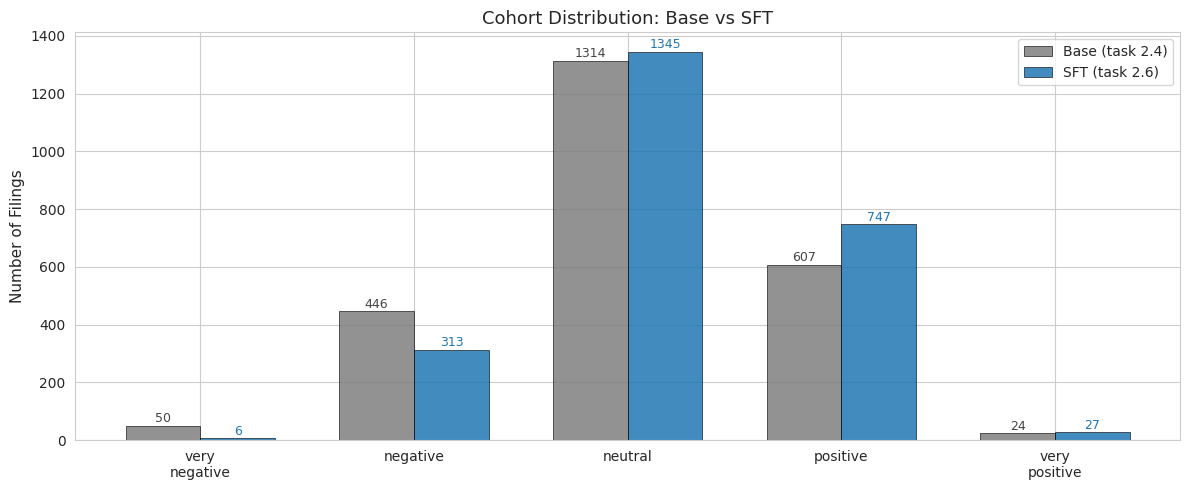

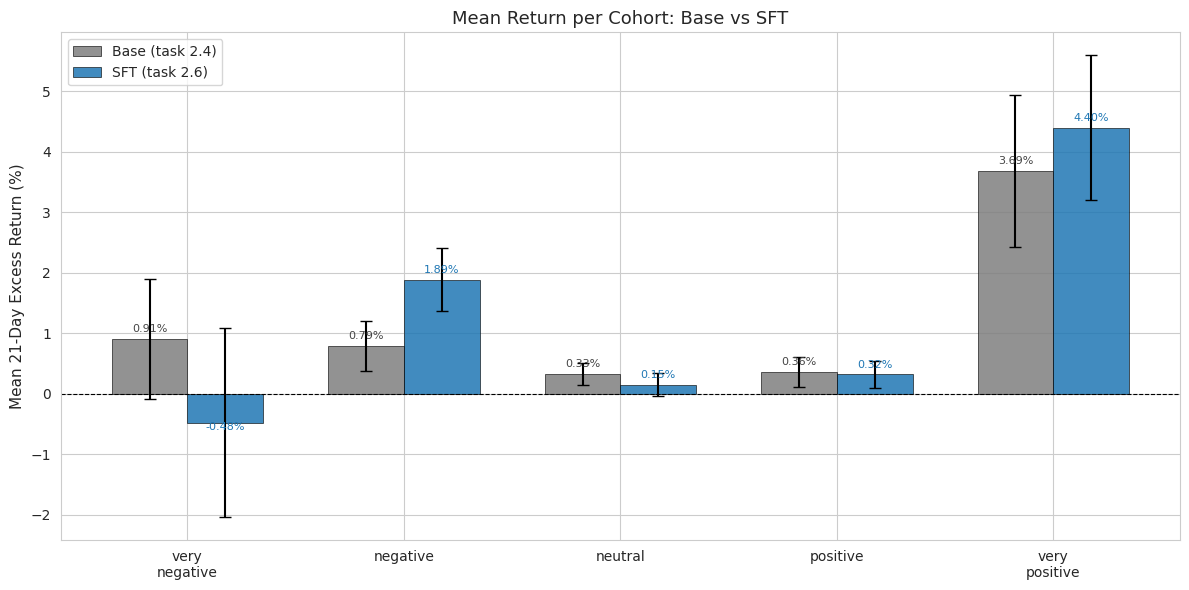


Metric                                               Base         SFT
----------------------------------------------------------------------
Spearman(signal, return) rho                       0.0128      0.0101
Spearman(signal, return) p-value               5.2660e-01  6.1783e-01
Long-short return (VP - VN) %                       2.778       4.880

  TASK 2.6 COMPLETE — SFT Multi-Agent Signal Consolidation


In [7]:
sns.set_style("whitegrid")
cohort_colors = ["#d62728", "#ff7f0e", "#999999", "#2ca02c", "#1f77b4"]

# ── SFT cohort distribution ──────────────────────────────────────────────
print("=" * 65)
print("  SFT COHORT DISTRIBUTION")
print("=" * 65)
sft_cohort_counts = filing_df["cohort"].value_counts().reindex(LABEL_ORDER)
for cohort, cnt in sft_cohort_counts.items():
    print(f"  {cohort:16s}: {cnt:5d} ({cnt/len(filing_df):.1%})")

# ── Spearman correlation: SFT signal vs returns ─────────────────────────
rho_sft, p_sft = spearmanr(filing_df["signal"], filing_df["ret_21d_excess"])
print(f"\nSpearman(SFT signal, ret_21d_excess): rho={rho_sft:.4f}, p={p_sft:.4e}")

# ── Mean return per cohort (SFT) ─────────────────────────────────────────
print(f"\nMean 21-day excess return per SFT cohort:")
print("-" * 50)
print(f"{'Cohort':>16s}  {'Count':>6s}  {'Mean Ret%':>10s}  {'Std%':>8s}")
print("-" * 50)
sft_cohort_stats = (
    filing_df.groupby("cohort", observed=False)["ret_21d_excess"]
    .agg(["mean", "std", "count", "sem"])
    .reindex(LABEL_ORDER)
)
for cohort in LABEL_ORDER:
    row = sft_cohort_stats.loc[cohort]
    n = int(row["count"])
    if n > 0:
        print(f"{cohort:>16s}  {n:6d}  {row['mean']*100:10.3f}  {row['std']*100:8.3f}")
    else:
        print(f"{cohort:>16s}  {n:6d}       N/A       N/A")

# ── Load base signals for comparison ─────────────────────────────────────
base_records = []
if BASE_SIGNALS_PATH.exists():
    with open(BASE_SIGNALS_PATH) as f:
        for line in f:
            base_records.append(json.loads(line))
    base_df = pd.DataFrame(base_records)
    base_df["cohort"] = pd.Categorical(base_df["cohort"], categories=LABEL_ORDER, ordered=True)
    print(f"\nLoaded {len(base_df)} base signals from {BASE_SIGNALS_PATH.name}")
else:
    base_df = None
    print(f"\nBase signals file not found at {BASE_SIGNALS_PATH} — skipping comparison.")

# ── Side-by-side cohort distribution: base vs SFT ────────────────────────
if base_df is not None:
    base_cohort_counts = base_df["cohort"].value_counts().reindex(LABEL_ORDER)

    print(f"\nSide-by-side cohort distribution:")
    print("-" * 55)
    print(f"{'Cohort':>16s}  {'Base':>8s}  {'SFT':>8s}  {'Delta':>8s}")
    print("-" * 55)
    for cohort in LABEL_ORDER:
        b = base_cohort_counts.get(cohort, 0)
        s = sft_cohort_counts.get(cohort, 0)
        delta = s - b
        sign = "+" if delta > 0 else ""
        print(f"{cohort:>16s}  {b:8d}  {s:8d}  {sign}{delta:7d}")

# ── Chart 1: Bar chart — base vs SFT cohort distributions ────────────────
if base_df is not None:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(LABEL_ORDER))
    width = 0.35

    base_vals = base_cohort_counts.reindex(LABEL_ORDER).fillna(0).values
    sft_vals = sft_cohort_counts.reindex(LABEL_ORDER).fillna(0).values

    bars_base = ax.bar(x - width / 2, base_vals, width, label="Base (task 2.4)",
                       color="#7f7f7f", edgecolor="black", linewidth=0.5, alpha=0.85)
    bars_sft = ax.bar(x + width / 2, sft_vals, width, label="SFT (task 2.6)",
                      color="#1f77b4", edgecolor="black", linewidth=0.5, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([l.replace("_", "\n") for l in LABEL_ORDER], fontsize=10)
    ax.set_ylabel("Number of Filings", fontsize=11)
    ax.set_title("Cohort Distribution: Base vs SFT", fontsize=13)
    ax.legend(fontsize=10)

    for bar, val in zip(bars_base, base_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(int(val)), ha="center", va="bottom", fontsize=9, color="#444444")
    for bar, val in zip(bars_sft, sft_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(int(val)), ha="center", va="bottom", fontsize=9, color="#1f77b4")

    plt.tight_layout()
    plt.show()

# ── Chart 2: Bar chart — base vs SFT mean returns per cohort ─────────────
if base_df is not None:
    base_cohort_ret = (
        base_df.groupby("cohort", observed=False)["ret_21d_excess"]
        .agg(["mean", "sem"])
        .reindex(LABEL_ORDER)
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(LABEL_ORDER))
    width = 0.35

    base_means = base_cohort_ret["mean"].fillna(0).values * 100
    base_sems = base_cohort_ret["sem"].fillna(0).values * 100
    sft_means = sft_cohort_stats["mean"].fillna(0).values * 100
    sft_sems = sft_cohort_stats["sem"].fillna(0).values * 100

    ax.bar(x - width / 2, base_means, width, yerr=base_sems, capsize=4,
           label="Base (task 2.4)", color="#7f7f7f", edgecolor="black",
           linewidth=0.5, alpha=0.85)
    ax.bar(x + width / 2, sft_means, width, yerr=sft_sems, capsize=4,
           label="SFT (task 2.6)", color="#1f77b4", edgecolor="black",
           linewidth=0.5, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([l.replace("_", "\n") for l in LABEL_ORDER], fontsize=10)
    ax.set_ylabel("Mean 21-Day Excess Return (%)", fontsize=11)
    ax.set_title("Mean Return per Cohort: Base vs SFT", fontsize=13)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.legend(fontsize=10)

    # Annotate means
    for i, (bm, sm) in enumerate(zip(base_means, sft_means)):
        ax.text(i - width / 2, bm + (0.08 if bm >= 0 else -0.15),
                f"{bm:.2f}%", ha="center", va="bottom", fontsize=8, color="#444444")
        ax.text(i + width / 2, sm + (0.08 if sm >= 0 else -0.15),
                f"{sm:.2f}%", ha="center", va="bottom", fontsize=8, color="#1f77b4")

    plt.tight_layout()
    plt.show()

    # ── Spearman comparison ──────────────────────────────────────────────
    cohort_rank_map = {c: i for i, c in enumerate(LABEL_ORDER)}
    base_df["cohort_rank"] = base_df["cohort"].map(cohort_rank_map)
    rho_base, p_base = spearmanr(base_df["signal"], base_df["ret_21d_excess"])

    print(f"\n{'Metric':<45s}  {'Base':>10s}  {'SFT':>10s}")
    print("-" * 70)
    print(f"{'Spearman(signal, return) rho':<45s}  {rho_base:10.4f}  {rho_sft:10.4f}")
    print(f"{'Spearman(signal, return) p-value':<45s}  {p_base:10.4e}  {p_sft:10.4e}")

    # Long-short returns
    for label, df_iter, name in [("Base", base_df, "base"), ("SFT", filing_df, "sft")]:
        vp = df_iter[df_iter["cohort"] == "very_positive"]["ret_21d_excess"].mean()
        vn = df_iter[df_iter["cohort"] == "very_negative"]["ret_21d_excess"].mean()
        ls = vp - vn if not (np.isnan(vp) or np.isnan(vn)) else np.nan
        if name == "base":
            ls_base = ls
        else:
            ls_sft = ls

    print(f"{'Long-short return (VP - VN) %':<45s}  {ls_base*100:10.3f}  {ls_sft*100:10.3f}")

print("\n" + "=" * 65)
print("  TASK 2.6 COMPLETE — SFT Multi-Agent Signal Consolidation")
print("=" * 65)